In [1]:
import struct
import csv
import numpy as np
import os

import matplotlib.pyplot as plt

x_array = np.array([])
y_array = np.array([])
z_array = np.array([])

sensor_data = {
    'adxl' : {
        'x' : [],
        'y' : [],
        'z' : [],
        'timestamps' : [],
        'sampling_rates' : [],
        'data_sizes' : [],
        'avg_sampling_rate' : 0
    },

    'bno' : {
        'acc_x' : [],
        'acc_y' : [],
        'acc_z' : [],
        'gyr_x' : [],
        'gyr_y' : [],
        'gyr_z' : [],
        'mag_x' : [],
        'mag_y' : [],
        'mag_z' : [],
        'eul_heading' : [],
        'eul_roll' : [],
        'eul_pitch' : [],
        'quat_w' : [],
        'quat_x' : [],
        'quat_y' : [],
        'quat_z' : [],
        'lia_x' : [],
        'lia_y' : [],
        'lia_z' : [],
        'grv_x' : [],
        'grv_y' : [],
        'grv_z' : [],
        'temp' : [],
        'single_size' : (6*3 + 6 + 8 + 6 + 6 + 1), # 45

        'timestamps' : [],
        'data_sizes' : [],
        'sampling_rates' : [],
        'avg_sampling_rate' : 0
    },

    'adc0' : {
        'values_ch1' : [],
        'values_ch2' : [],
        'timestamps' : [],
        'data_sizes' : [],
        'sampling_rates' : [],
        'avg_sampling_rate' : 0
    }
}

def bytes_to_data(bytes_read, number_of_values):
    # Unpack 6 uint8_t values
    u = struct.unpack(f'{number_of_values*2}B', bytes_read)
    output = []
    for i in range(0, number_of_values):
        val = (u[i*2 + 1] << 8) | u[i*2]
        # Interpret as signed int16
        val = struct.unpack('<h', struct.pack('<H', val))[0]
        output.append(val)
    return output

with open('adxl_400_00.bin', 'rb') as bin_file:
    first_header = bin_file.read(4)
    # HAL_GetTick() is a uint32_t copied with memcpy — assume little-endian
    global_start_time = struct.unpack('<I', first_header)[0]
    print(f"global_start_time_ms = {global_start_time}")
    while True:
        header = bin_file.read(9)
        if len(header) < 9:
            break
        index = header[0]
        timestamp = struct.unpack('<I', header[1:5])[0]
        data_size = struct.unpack('<I', header[5:9])[0]
        print(f"Index: {index}, Timestamp: {timestamp}, Data size: {data_size}")
        if index == 1:
            start_time = sensor_data['adxl']['timestamps'][-1] if sensor_data['adxl']['timestamps'] else global_start_time
            sensor_data['adxl']['timestamps'].append(timestamp)
            sensor_data['adxl']['data_sizes'].append(int(data_size / 6))
            sampling_rate = (data_size / 6) / ((timestamp - start_time) / 1000)
            sensor_data['adxl']['sampling_rates'].append(sampling_rate)
            for _ in range(data_size//6):
                bytes_read = bin_file.read(6)
                if len(bytes_read) < 6:
                    break
                data = bytes_to_data(bytes_read, 3)
                sensor_data['adxl']['x'].append(data[0] / 2048.0)
                sensor_data['adxl']['y'].append(data[1] / 2048.0)
                sensor_data['adxl']['z'].append(data[2] / 2048.0)
        elif index == 2:
            start_time = sensor_data['bno']['timestamps'][-1] if sensor_data['bno']['timestamps'] else global_start_time
            sensor_data['bno']['timestamps'].append(timestamp)
            sensor_data['bno']['data_sizes'].append(int(data_size / sensor_data['bno']['single_size']))
            sampling_rate = (data_size / sensor_data['bno']['single_size']) / ((timestamp - start_time) / 1000)
            sensor_data['bno']['sampling_rates'].append(sampling_rate)
            for _ in range(data_size//sensor_data['bno']['single_size']):
                bytes_read = bin_file.read(6)
                if len(bytes_read) < 6:
                    break
                data = bytes_to_data(bytes_read, 3)
                sensor_data['bno']['acc_x'].append(data[0]/100.0)
                sensor_data['bno']['acc_y'].append(data[1]/100.0)
                sensor_data['bno']['acc_z'].append(data[2]/100.0)
                bytes_read = bin_file.read(6)
                if len(bytes_read) < 6:
                    break
                data = bytes_to_data(bytes_read, 3)
                sensor_data['bno']['gyr_x'].append(data[0]/16.0)
                sensor_data['bno']['gyr_y'].append(data[1]/16.0)
                sensor_data['bno']['gyr_z'].append(data[2]/16.0)
                bytes_read = bin_file.read(6)
                if len(bytes_read) < 6:
                    break
                data = bytes_to_data(bytes_read, 3)
                sensor_data['bno']['mag_x'].append(data[0]/16.0)
                sensor_data['bno']['mag_y'].append(data[1]/16.0)
                sensor_data['bno']['mag_z'].append(data[2]/16.0)
                bytes_read = bin_file.read(6)
                if len(bytes_read) < 6:
                    break
                data = bytes_to_data(bytes_read, 3)
                sensor_data['bno']['eul_heading'].append(data[0]/16.0)
                sensor_data['bno']['eul_roll'].append(data[1]/16.0)
                sensor_data['bno']['eul_pitch'].append(data[2]/16.0)
                bytes_read = bin_file.read(8)
                if len(bytes_read) < 8:
                    break
                data = bytes_to_data(bytes_read, 4)
                sensor_data['bno']['quat_w'].append(data[0]/16384.0)
                sensor_data['bno']['quat_x'].append(data[1]/16384.0)
                sensor_data['bno']['quat_y'].append(data[2]/16384.0)
                sensor_data['bno']['quat_z'].append(data[3]/16384.0)
                bytes_read = bin_file.read(6)
                if len(bytes_read) < 6:
                    break
                data = bytes_to_data(bytes_read, 3)
                sensor_data['bno']['lia_x'].append(data[0]/100.0)
                sensor_data['bno']['lia_y'].append(data[1]/100.0)
                sensor_data['bno']['lia_z'].append(data[2]/100.0)
                bytes_read = bin_file.read(6)
                if len(bytes_read) < 6:
                    break
                data = bytes_to_data(bytes_read, 3)
                sensor_data['bno']['grv_x'].append(data[0]/100.0)
                sensor_data['bno']['grv_y'].append(data[1]/100.0)
                sensor_data['bno']['grv_z'].append(data[2]/100.0)
                bytes_read = bin_file.read(1)
                if len(bytes_read) < 1:
                    break
                u = struct.unpack('1B', bytes_read)
                sensor_data['bno']['temp'].append(u[0])
        elif index == 3:
            start_time = sensor_data['adc0']['timestamps'][-1] if sensor_data['adc0']['timestamps'] else global_start_time
            sensor_data['adc0']['timestamps'].append(timestamp)
            sampling_rate = (data_size / 4) / ((timestamp - start_time) / 1000)
            sensor_data['adc0']['sampling_rates'].append(sampling_rate)
            sensor_data['adc0']['data_sizes'].append(int(data_size / 4))
            for _ in range(data_size // 4):
                bytes_read = bin_file.read(4)  # 2 bytes for CH1 + 2 bytes for CH2
                if len(bytes_read) < 4:
                    break

                ch1, ch2 = struct.unpack('<HH', bytes_read)  # little-endian uint16, uint16
                sensor_data['adc0']['values_ch1'].append(ch1)
                sensor_data['adc0']['values_ch2'].append(ch2)


global_start_time_ms = 41680
Index: 1, Timestamp: 45184, Data size: 8226
Index: 1, Timestamp: 48801, Data size: 8286
Index: 1, Timestamp: 52405, Data size: 8256
Index: 1, Timestamp: 55989, Data size: 8208
Index: 1, Timestamp: 58610, Data size: 6012


In [2]:

# Calculate average sampling rates excluding the last element
if len(sensor_data['adxl']['sampling_rates']) > 1:
    rates = sensor_data['adxl']['sampling_rates'][:-1]
    sensor_data['adxl']['avg_sampling_rate'] = sum(rates) / len(rates)
    print(f"ADXL Average Sampling Rate: {sensor_data['adxl']['avg_sampling_rate']} Hz")

if len(sensor_data['bno']['sampling_rates']) > 1:
    rates = sensor_data['bno']['sampling_rates'][:-1]
    sensor_data['bno']['avg_sampling_rate'] = sum(rates) / len(rates)
    print(f"BNO Average Sampling Rate: {sensor_data['bno']['avg_sampling_rate']} Hz")

if len(sensor_data['adc0']['sampling_rates']) > 1:
    rates = sensor_data['adc0']['sampling_rates'][:-1]
    sensor_data['adc0']['avg_sampling_rate'] = sum(rates) / len(rates)
    print(f"ADC0 Average Sampling Rate: {sensor_data['adc0']['avg_sampling_rate']} Hz")

ADXL Average Sampling Rate: 384.14242059049076 Hz


IndexError: index 0 is out of bounds for axis 0 with size 0

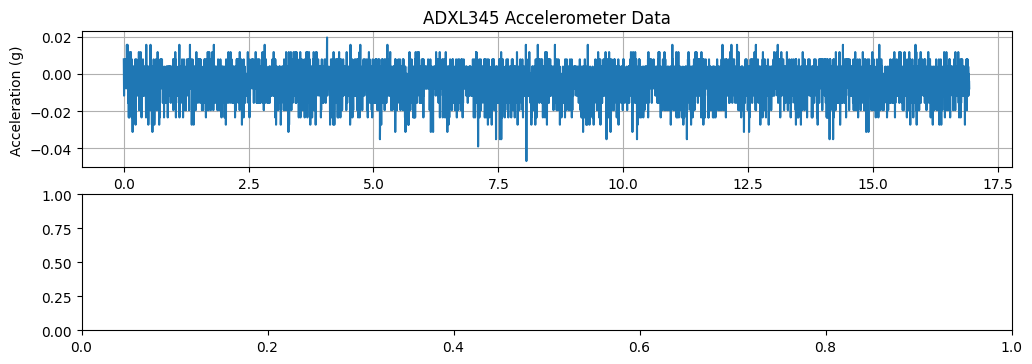

In [3]:
def _unwrap_deg(vals):
    unwrapped = np.rad2deg(np.unwrap(np.deg2rad(vals), discont=np.deg2rad(180.0)))
    offset = np.round(unwrapped[0] / 360.0) * 360.0
    return unwrapped - offset


t_adxl = np.array([])
t_bno = np.array([])
t_adc0 = np.array([])

for i in range(0, len(sensor_data['adxl']['sampling_rates'])):
    partial_time = np.linspace((t_adxl[-1] if t_adxl.size > 0 else 0), (t_adxl[-1] if t_adxl.size > 0 else 0) + sensor_data['adxl']['data_sizes'][i] / sensor_data['adxl']['sampling_rates'][i], num=sensor_data['adxl']['data_sizes'][i])

    t_adxl = np.concatenate((t_adxl, partial_time))

for i in range(0, len(sensor_data['bno']['sampling_rates'])):
    partial_time = np.linspace((t_bno[-1] if t_bno.size > 0 else 0), (t_bno[-1] if t_bno.size > 0 else 0) + sensor_data['bno']['data_sizes'][i] / sensor_data['bno']['sampling_rates'][i], num=sensor_data['bno']['data_sizes'][i])

    t_bno = np.concatenate((t_bno, partial_time))

for i in range(0, len(sensor_data['adc0']['sampling_rates'])):
    partial_time = np.linspace((t_adc0[-1] if t_adc0.size > 0 else 0), (t_adc0[-1] if t_adc0.size > 0 else 0) + sensor_data['adc0']['data_sizes'][i] / sensor_data['adc0']['sampling_rates'][i], num=sensor_data['adc0']['data_sizes'][i])

    t_adc0 = np.concatenate((t_adc0, partial_time))

plt.figure(1, figsize=(12, 6))
plt.subplot(3, 1, 1)
plt.plot(t_adxl, sensor_data['adxl']['x'], label='X-axis')
plt.title('ADXL345 Accelerometer Data')
plt.ylabel('Acceleration (g)')
plt.grid()

plt.subplot(3, 1, 2)
plt.plot(t_bno, _unwrap_deg(sensor_data['bno']['eul_roll']), label='BNO Eul Roll')
plt.title('BNO Eul Roll Data')
plt.ylabel('Roll (degrees)')
plt.yticks(np.arange(-45, 46, 22.5))
plt.grid()

plt.subplot(3, 1, 3)
plt.plot(t_adc0, sensor_data['adc0']['values_ch1'], label='ADC0 CH1')
plt.title('ADC0 CH1 Data')
plt.ylabel('ADC Value')
plt.yticks(np.arange(4096, 12289, 4096))
plt.ylim(4096, 12288)
plt.xlabel('Time (s)')
plt.grid()
plt.tight_layout()


# Export CSV

In [3]:

max_digits = 6
adxl_file = 'output_adxl_data.csv'
with open(adxl_file, 'w', newline='') as adxl_file:
    writer = csv.writer(adxl_file)
    writer.writerow(['t', 'X', 'Y', 'Z'])
    for i in range(len(sensor_data['adxl']['x'])):
        writer.writerow([round(i / sensor_data['adxl']['avg_sampling_rate'], max_digits), 
                         round(sensor_data['adxl']['x'][i], max_digits), 
                         round(sensor_data['adxl']['y'][i], max_digits), 
                         round(sensor_data['adxl']['z'][i], max_digits)])

max_digits = 6
bno_file = 'output_bno_data.csv'
with open(bno_file, 'w', newline='') as bno_csvfile:
    writer = csv.writer(bno_csvfile)
    writer.writerow(['t', 
                        'acc_X', 'acc_Y', 'acc_Z', 
                        'gyr_X', 'gyr_Y', 'gyr_Z', 
                        'mag_X', 'mag_Y', 'mag_Z',
                        'eul_heading', 'eul_roll', 'eul_pitch',
                        'quat_w', 'quat_x', 'quat_y', 'quat_z',
                        'lia_X', 'lia_Y', 'lia_Z',
                        'grv_X', 'grv_Y', 'grv_Z',
                        'temp'])
    for i in range(len(sensor_data['bno']['acc_x'])):
        writer.writerow([round(i / sensor_data['bno']['avg_sampling_rate'], max_digits), 
                round(sensor_data['bno']['acc_x'][i], max_digits), round(sensor_data['bno']['acc_y'][i], max_digits), round(sensor_data['bno']['acc_z'][i], max_digits), 
                round(sensor_data['bno']['gyr_x'][i], max_digits), round(sensor_data['bno']['gyr_y'][i], max_digits), round(sensor_data['bno']['gyr_z'][i], max_digits), 
                round(sensor_data['bno']['mag_x'][i], max_digits), round(sensor_data['bno']['mag_y'][i], max_digits), round(sensor_data['bno']['mag_z'][i], max_digits),
                round(sensor_data['bno']['eul_heading'][i], max_digits), round(sensor_data['bno']['eul_roll'][i], max_digits), round(sensor_data['bno']['eul_pitch'][i], max_digits),
                round(sensor_data['bno']['quat_w'][i], max_digits), round(sensor_data['bno']['quat_x'][i], max_digits), round(sensor_data['bno']['quat_y'][i], max_digits), round(sensor_data['bno']['quat_z'][i], max_digits),
                round(sensor_data['bno']['lia_x'][i], max_digits), round(sensor_data['bno']['lia_y'][i], max_digits), round(sensor_data['bno']['lia_z'][i], max_digits),
                round(sensor_data['bno']['grv_x'][i], max_digits), round(sensor_data['bno']['grv_y'][i], max_digits), round(sensor_data['bno']['grv_z'][i], max_digits),
                round(sensor_data['bno']['temp'][i], max_digits)])

max_digits = 6
adc0_file = 'output_adc0_data.csv'
with open(adc0_file, 'w', newline='') as adc0_csvfile:
    writer = csv.writer(adc0_csvfile)
    writer.writerow(['t', 'ADC0', 'ADC1'])
    for i in range(len(sensor_data['adc0']['values_ch1'])):
        writer.writerow([round(i / sensor_data['adc0']['avg_sampling_rate'], max_digits), 
                         round(sensor_data['adc0']['values_ch1'][i], max_digits), 
                         round(sensor_data['adc0']['values_ch2'][i], max_digits)])
        

# Export JSON

In [36]:
import json
import os

def write_sensor_data_json(output_path, device_id=201):
    adxl_outputs = [
        {
            "acc_x": {
                "Units": "m/s^2",
                "Description": "Acceleration in X direction",
                "Data type": "float",
                "Sampling rate (Hz)": sensor_data["adxl"]["avg_sampling_rate"],
                "Data length": len(sensor_data["adxl"]["x"]),
                "Data": list(sensor_data["adxl"]["x"]),
            }
        },
        {
            "acc_y": {
                "Units": "m/s^2",
                "Description": "Acceleration in Y direction",
                "Data type": "float",
                "Sampling rate (Hz)": sensor_data["adxl"]["avg_sampling_rate"],
                "Data length": len(sensor_data["adxl"]["y"]),
                "Data": list(sensor_data["adxl"]["y"]),
            }
        },
        {
            "acc_z": {
                "Units": "m/s^2",
                "Description": "Acceleration in Z direction",
                "Data type": "float",
                "Sampling rate (Hz)": sensor_data["adxl"]["avg_sampling_rate"],
                "Data length": len(sensor_data["adxl"]["z"]),
                "Data": list(sensor_data["adxl"]["z"]),
            }
        },
    ]

    bno_outputs = [
        {
            "acc_x": {
                "Units": "m/s^2",
                "Description": "Acceleration in X direction",
                "Data type": "float",
                "Sampling rate (Hz)": sensor_data["bno"]["avg_sampling_rate"],
                "Data length": len(sensor_data["bno"]["acc_x"]),
                "Data": list(sensor_data["bno"]["acc_x"]),
            }
        },
        {
            "acc_y": {
                "Units": "m/s^2",
                "Description": "Acceleration in Y direction",
                "Data type": "float",
                "Sampling rate (Hz)": sensor_data["bno"]["avg_sampling_rate"],
                "Data length": len(sensor_data["bno"]["acc_y"]),
                "Data": list(sensor_data["bno"]["acc_y"]),
            }
        },
        {
            "acc_z": {
                "Units": "m/s^2",
                "Description": "Acceleration in Z direction",
                "Data type": "float",
                "Sampling rate (Hz)": sensor_data["bno"]["avg_sampling_rate"],
                "Data length": len(sensor_data["bno"]["acc_z"]),
                "Data": list(sensor_data["bno"]["acc_z"]),
            }
        },
        {
            "gyr_x": {
                "Units": "deg/s",
                "Description": "Angular velocity in X direction",
                "Data type": "float",
                "Sampling rate (Hz)": sensor_data["bno"]["avg_sampling_rate"],
                "Data length": len(sensor_data["bno"]["gyr_x"]),
                "Data": list(sensor_data["bno"]["gyr_x"]),
            }
        },
        {
            "gyr_y": {
                "Units": "deg/s",
                "Description": "Angular velocity in Y direction",
                "Data type": "float",
                "Sampling rate (Hz)": sensor_data["bno"]["avg_sampling_rate"],
                "Data length": len(sensor_data["bno"]["gyr_y"]),
                "Data": list(sensor_data["bno"]["gyr_y"]),
            }
        },
        {
            "gyr_z": {
                "Units": "deg/s",
                "Description": "Angular velocity in Z direction",
                "Data type": "float",
                "Sampling rate (Hz)": sensor_data["bno"]["avg_sampling_rate"],
                "Data length": len(sensor_data["bno"]["gyr_z"]),
                "Data": list(sensor_data["bno"]["gyr_z"]),
            }
        },
        {
            "mag_x": {
                "Units": "uT",
                "Description": "Magnetic field in X direction",
                "Data type": "float",
                "Sampling rate (Hz)": sensor_data["bno"]["avg_sampling_rate"],
                "Data length": len(sensor_data["bno"]["mag_x"]),
                "Data": list(sensor_data["bno"]["mag_x"]),
            }
        },
        {
            "mag_y": {
                "Units": "uT",
                "Description": "Magnetic field in Y direction",
                "Data type": "float",
                "Sampling rate (Hz)": sensor_data["bno"]["avg_sampling_rate"],
                "Data length": len(sensor_data["bno"]["mag_y"]),
                "Data": list(sensor_data["bno"]["mag_y"]),
            }
        },
        {
            "mag_z": {
                "Units": "uT",
                "Description": "Magnetic field in Z direction",
                "Data type": "float",
                "Sampling rate (Hz)": sensor_data["bno"]["avg_sampling_rate"],
                "Data length": len(sensor_data["bno"]["mag_z"]),
                "Data": list(sensor_data["bno"]["mag_z"]),
            }
        },
        {
            "eul_heading": {
                "Units": "deg",
                "Description": "Euler heading angle",
                "Data type": "float",
                "Sampling rate (Hz)": sensor_data["bno"]["avg_sampling_rate"],
                "Data length": len(sensor_data["bno"]["eul_heading"]),
                "Data": list(sensor_data["bno"]["eul_heading"]),
            }
        },
        {
            "eul_roll": {
                "Units": "deg",
                "Description": "Euler roll angle",
                "Data type": "float",
                "Sampling rate (Hz)": sensor_data["bno"]["avg_sampling_rate"],
                "Data length": len(sensor_data["bno"]["eul_roll"]),
                "Data": list(sensor_data["bno"]["eul_roll"]),
            }
        },
        {
            "eul_pitch": {
                "Units": "deg",
                "Description": "Euler pitch angle",
                "Data type": "float",
                "Sampling rate (Hz)": sensor_data["bno"]["avg_sampling_rate"],
                "Data length": len(sensor_data["bno"]["eul_pitch"]),
                "Data": list(sensor_data["bno"]["eul_pitch"]),
            }
        },
        {
            "quat_w": {
                "Units": "",
                "Description": "Quaternion w component",
                "Data type": "float",
                "Sampling rate (Hz)": sensor_data["bno"]["avg_sampling_rate"],
                "Data length": len(sensor_data["bno"]["quat_w"]),
                "Data": list(sensor_data["bno"]["quat_w"]),
            }
        },
        {
            "quat_x": {
                "Units": "",
                "Description": "Quaternion x component",
                "Data type": "float",
                "Sampling rate (Hz)": sensor_data["bno"]["avg_sampling_rate"],
                "Data length": len(sensor_data["bno"]["quat_x"]),
                "Data": list(sensor_data["bno"]["quat_x"]),
            }
        },
        {
            "quat_y": {
                "Units": "",
                "Description": "Quaternion y component",
                "Data type": "float",
                "Sampling rate (Hz)": sensor_data["bno"]["avg_sampling_rate"],
                "Data length": len(sensor_data["bno"]["quat_y"]),
                "Data": list(sensor_data["bno"]["quat_y"]),
            }
        },
        {
            "quat_z": {
                "Units": "",
                "Description": "Quaternion z component",
                "Data type": "float",
                "Sampling rate (Hz)": sensor_data["bno"]["avg_sampling_rate"],
                "Data length": len(sensor_data["bno"]["quat_z"]),
                "Data": list(sensor_data["bno"]["quat_z"]),
            }
        },
        {
            "lia_x": {
                "Units": "m/s^2",
                "Description": "Linear acceleration in X direction",
                "Data type": "float",
                "Sampling rate (Hz)": sensor_data["bno"]["avg_sampling_rate"],
                "Data length": len(sensor_data["bno"]["lia_x"]),
                "Data": list(sensor_data["bno"]["lia_x"]),
            }
        },
        {
            "lia_y": {
                "Units": "m/s^2",
                "Description": "Linear acceleration in Y direction",
                "Data type": "float",
                "Sampling rate (Hz)": sensor_data["bno"]["avg_sampling_rate"],
                "Data length": len(sensor_data["bno"]["lia_y"]),
                "Data": list(sensor_data["bno"]["lia_y"]),
            }
        },
        {
            "lia_z": {
                "Units": "m/s^2",
                "Description": "Linear acceleration in Z direction",
                "Data type": "float",
                "Sampling rate (Hz)": sensor_data["bno"]["avg_sampling_rate"],
                "Data length": len(sensor_data["bno"]["lia_z"]),
                "Data": list(sensor_data["bno"]["lia_z"]),
            }
        },
        {
            "grv_x": {
                "Units": "m/s^2",
                "Description": "Gravity acceleration in X direction",
                "Data type": "float",
                "Sampling rate (Hz)": sensor_data["bno"]["avg_sampling_rate"],
                "Data length": len(sensor_data["bno"]["grv_x"]),
                "Data": list(sensor_data["bno"]["grv_x"]),
            }
        },
        {
            "grv_y": {
                "Units": "m/s^2",
                "Description": "Gravity acceleration in Y direction",
                "Data type": "float",
                "Sampling rate (Hz)": sensor_data["bno"]["avg_sampling_rate"],
                "Data length": len(sensor_data["bno"]["grv_y"]),
                "Data": list(sensor_data["bno"]["grv_y"]),
            }
        },
        {
            "grv_z": {
                "Units": "m/s^2",
                "Description": "Gravity acceleration in Z direction",
                "Data type": "float",
                "Sampling rate (Hz)": sensor_data["bno"]["avg_sampling_rate"],
                "Data length": len(sensor_data["bno"]["grv_z"]),
                "Data": list(sensor_data["bno"]["grv_z"]),
            }
        },
        {
            "temp": {
                "Units": "C",
                "Description": "Temperature",
                "Data type": "float",
                "Sampling rate (Hz)": sensor_data["bno"]["avg_sampling_rate"],
                "Data length": len(sensor_data["bno"]["temp"]),
                "Data": list(sensor_data["bno"]["temp"]),
            }
        },
    ]

    adc_outputs = [
        {
            "AI1": {
                "Units": "V",
                "Description": "Values from analog input 1 in volts",
                "Data type": "float",
                "Sampling rate (Hz)": sensor_data["adc0"]["avg_sampling_rate"],
                "Data length": len(sensor_data["adc0"]["values"]),
                "Data": list(sensor_data["adc0"]["values"]),
            }
        },
        {
            "AI2": {
                "Units": "V",
                "Description": "Values from analog input 2 in volts",
                "Data type": "float",
                "Sampling rate (Hz)": sensor_data["adc0"]["avg_sampling_rate"],
                "Data length": 0,
                "Data": [],
            }
        },
    ]

    output_json = {
        "Device": device_id,
        "Sensor data": [
            {"Sensor": "ADXL345", "Outputs": adxl_outputs},
            {"Sensor": "BNO055", "Outputs": bno_outputs},
            {"Sensor": "Analog Input", "Outputs": adc_outputs},
        ],
    }

    with open(output_path, "w", encoding="utf-8") as json_file:
        json.dump(output_json, json_file, indent=4)


json_output_path = os.path.join(os.getcwd(), "output_data.json")
write_sensor_data_json(json_output_path)
print(f"Wrote {json_output_path}")


KeyError: 'values'

# Plot ADXL345 data

Wrote c:\Users\marek\Documents\Python_scripts\PyQt\Accelerometer_control_app\plots\adxl_accelerometer_data.pdf


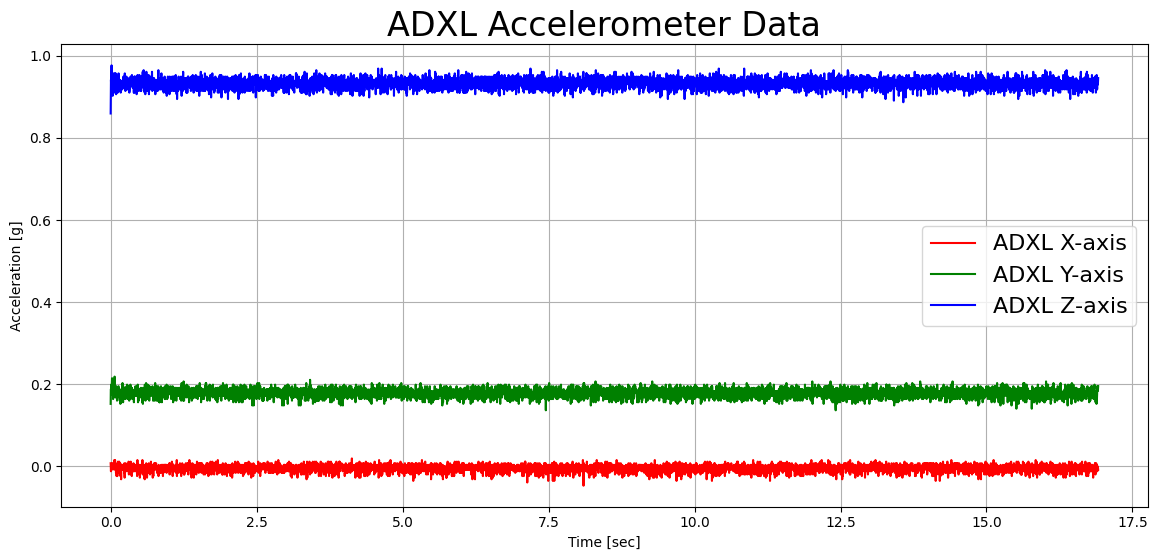

In [4]:
fig, ax = plt.subplots(figsize=(12, 6))
t_start = 0
t_end = 2000

full_t = np.arange(len(sensor_data['adxl']['x'])) / sensor_data['adxl']['avg_sampling_rate']
mask = (full_t >= t_start) & (full_t <= t_end)

plt.rcParams.update({
    "font.size": 20,
    "axes.titlesize": 24,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 16,
})
ax.plot(full_t[mask] - t_start, np.asarray(sensor_data['adxl']['x'])[mask], label='ADXL X-axis', color='r')
ax.plot(full_t[mask] - t_start, np.asarray(sensor_data['adxl']['y'])[mask], label='ADXL Y-axis', color='g')
ax.plot(full_t[mask] - t_start, np.asarray(sensor_data['adxl']['z'])[mask], label='ADXL Z-axis', color='b')
ax.set_xlabel('Time [sec]')
ax.set_ylabel('Acceleration [g]')
ax.set_title('ADXL Accelerometer Data')
ax.legend()
ax.grid(True)
fig.tight_layout()

pdf_output_path = os.path.join(os.getcwd(), "plots", "adxl_accelerometer_data.pdf")
os.makedirs(os.path.dirname(pdf_output_path), exist_ok=True)
fig.savefig(pdf_output_path, format="pdf", bbox_inches="tight")
print(f"Wrote {pdf_output_path}")

plt.show()



C:\Users\marek\AppData\Local\Temp\ipykernel_23452\1075759010.py:55: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax_fft.set_xlim(0, max_freq_hz)


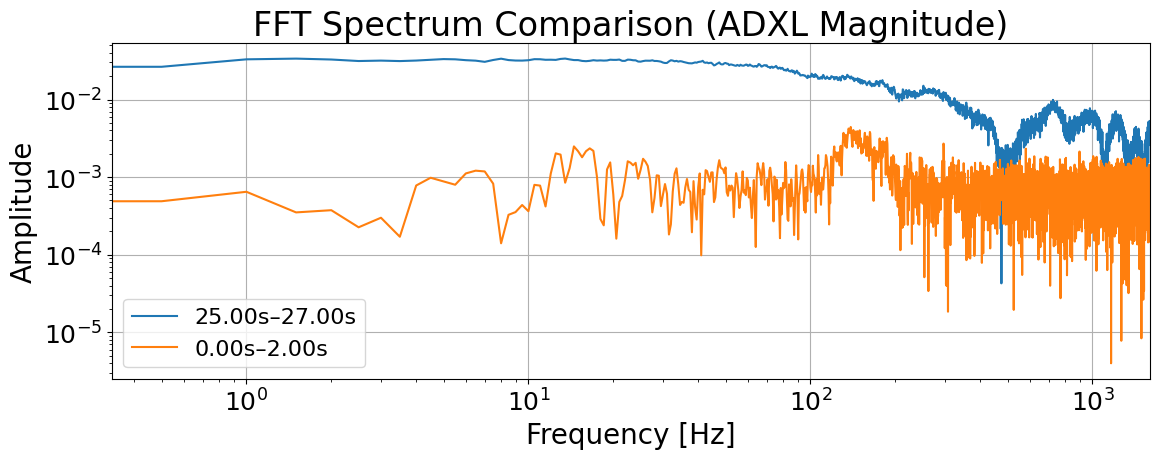

In [20]:
# FFT comparison for two distinct ADXL time windows on one graph

# --- User-defined windows [s] ---
t_start_1 = 25
start_end_1 = 27
t_start_2 = 0
start_end_2 = 2

# Optional display limit
max_freq_hz = 1600

x = np.asarray(sensor_data["adxl"]["x"], dtype=float)
y = np.asarray(sensor_data["adxl"]["y"], dtype=float)
z = np.asarray(sensor_data["adxl"]["z"], dtype=float)
n = min(len(x), len(y), len(z))
sig = np.sqrt(x[:n] ** 2 + y[:n] ** 2 + z[:n] ** 2)

fs = float(sensor_data["adxl"]["avg_sampling_rate"])
if fs <= 0:
    raise ValueError("Invalid ADXL sampling rate.")

t_sig = np.arange(len(sig)) / fs

def fft_from_window(signal, t_axis, t0, t1, fs_hz):
    if t1 <= t0:
        raise ValueError(f"Invalid window: t_start={t0}, t_end={t1}")
    m = (t_axis >= t0) & (t_axis <= t1)
    s = signal[m]
    if len(s) < 8:
        raise ValueError(f"Window [{t0}, {t1}] has too few samples ({len(s)}).")

    s = s - np.mean(s)
    w = np.hanning(len(s))
    yf = np.fft.rfft(s * w)
    xf = np.fft.rfftfreq(len(s), d=1.0 / fs_hz)
    amp = (2.0 / np.sum(w)) * np.abs(yf)
    return xf, amp

f1, a1 = fft_from_window(sig, t_sig, t_start_1, start_end_1, fs)
f2, a2 = fft_from_window(sig, t_sig, t_start_2, start_end_2, fs)

fig_fft, ax_fft = plt.subplots(figsize=(12, 5))
ax_fft.plot(f1, a1, color="tab:blue", label=f"{t_start_1:.2f}s–{start_end_1:.2f}s")
ax_fft.plot(f2, a2, color="tab:orange", label=f"{t_start_2:.2f}s–{start_end_2:.2f}s")

ax_fft.set_title("FFT Spectrum Comparison (ADXL Magnitude)")
ax_fft.set_xlabel("Frequency [Hz]")
ax_fft.set_xscale("log")
ax_fft.set_ylabel("Amplitude")
ax_fft.set_yscale("log")
ax_fft.grid(True)
ax_fft.legend()

if max_freq_hz is not None:
    ax_fft.set_xlim(0, max_freq_hz)

fig_fft.tight_layout()
plt.show()


Wrote c:\Users\marek\Documents\Python_scripts\PyQt\Accelerometer_control_app\plots\adxl_wavelet_scalogram.pdf


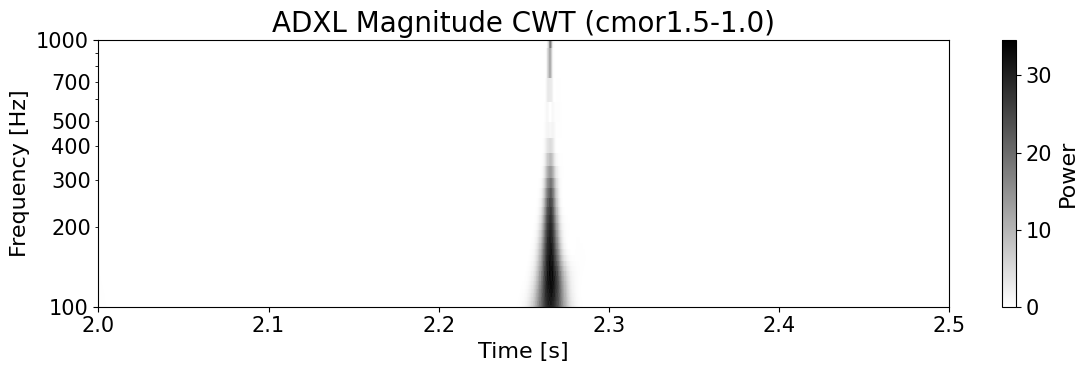

In [9]:
import pywt
from matplotlib.ticker import FuncFormatter

# Wavelet transform (CWT) for ADXL data in a selected time window, with PDF export

# --- User parameters ---
t_start = 2   # [s]
t_end = 2.5    # [s]
wavelet_name = "cmor1.5-1.0"
scales = np.arange(1, 512)  # increase max for better low-frequency resolution

# --- Prepare data ---
fs = sensor_data["adxl"]["avg_sampling_rate"]
if fs <= 0:
    raise ValueError("ADXL average sampling rate is not valid. Run sampling-rate calculation first.")

axes_data = {
    "X": np.asarray(sensor_data["adxl"]["x"], dtype=float),
    "Y": np.asarray(sensor_data["adxl"]["y"], dtype=float),
    "Z": np.asarray(sensor_data["adxl"]["z"], dtype=float),
}

n = min(len(v) for v in axes_data.values())
if n == 0:
    raise ValueError("No ADXL samples found.")

t = np.arange(n) / fs
t_start = max(0.0, float(t_start))
t_end = min(float(t_end), t[-1])

if t_end <= t_start:
    raise ValueError(f"Invalid window: t_start={t_start}, t_end={t_end}")

mask = (t >= t_start) & (t <= t_end)
t_win = t[mask]

# --- Compute overall magnitude and plot ---
x = axes_data["X"][:n]
y = axes_data["Y"][:n]
z = axes_data["Z"][:n]
module = np.sqrt(x**2 + y**2 + z**2)
module_win = module[mask]

coeffs, freqs = pywt.cwt(module_win, scales, wavelet_name, sampling_period=1.0 / fs)
power = np.abs(coeffs) ** 2

plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 20,
    "axes.labelsize": 16,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 12,
})
fig, ax = plt.subplots(figsize=(12, 4))

# Use rasterized=True to massively speed up rendering and reduce PDF file size 
# for dense data like a scalogram.
pcm = ax.pcolormesh(t_win, freqs, power, shading="auto", cmap="gray_r", rasterized=True)

ax.set_xlabel("Time [s]")
ax.set_ylabel("Frequency [Hz]")
ax.set_title(f"ADXL Magnitude CWT ({wavelet_name})")
ax.set_yscale("log")
ax.set_ylim(100, 1000)
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{int(y)}'))
minor_ticks_to_show = [100, 200, 300, 400, 500, 700]
ax.yaxis.set_minor_formatter(FuncFormatter(lambda y, _: f'{int(y)}' if int(y) in minor_ticks_to_show else ''))
fig.colorbar(pcm, ax=ax, label="Power")

plt.tight_layout()

# --- Export PDF ---
pdf_output_path = os.path.join(os.getcwd(), "plots", "adxl_wavelet_scalogram.pdf")
os.makedirs(os.path.dirname(pdf_output_path), exist_ok=True)
# Ensure dpi is set for the rasterized components
fig.savefig(pdf_output_path, format="pdf", bbox_inches="tight", dpi=300)
print(f"Wrote {pdf_output_path}")


# Plot BNO055 ACC+GYR+MAG data

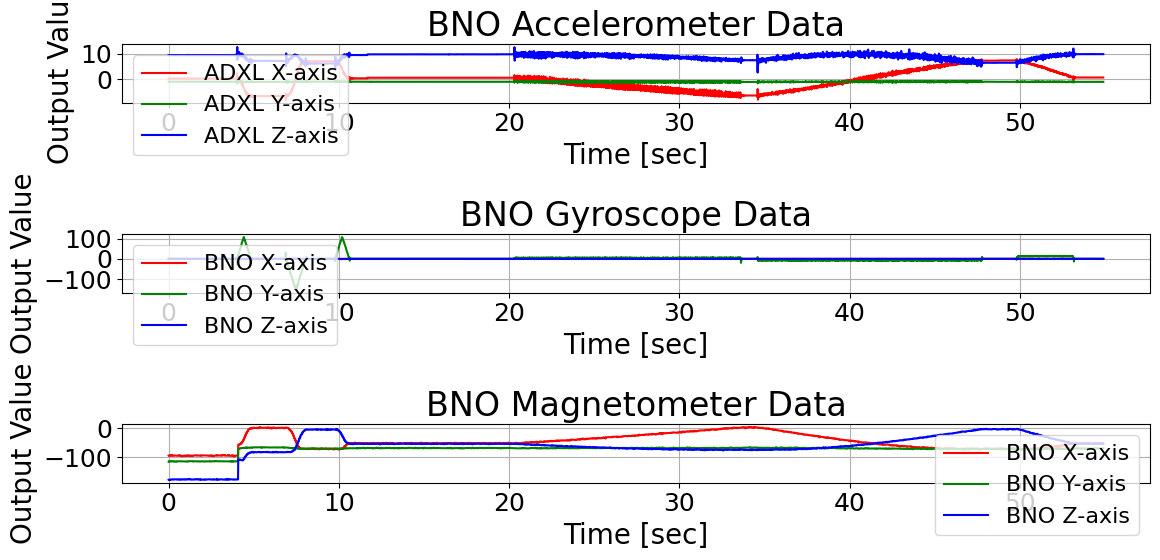

In [4]:
plt.figure(1, figsize=(12, 6))
plt.subplot(3, 1, 1)
t = [i / sensor_data['bno']['avg_sampling_rate'] for i in range(len(sensor_data['bno']['acc_x']))]  # Assuming a sampling rate of 3200 Hz for ADXL
plt.plot(t, sensor_data['bno']['acc_x'], label='ADXL X-axis', color='r')
plt.plot(t, sensor_data['bno']['acc_y'], label='ADXL Y-axis', color='g')
plt.plot(t, sensor_data['bno']['acc_z'], label='ADXL Z-axis', color='b')
plt.xlabel('Time [sec]')
plt.ylabel('Output Value')
plt.title('BNO Accelerometer Data')
plt.legend()
plt.grid(True)
plt.subplot(3, 1, 2)
t = [i / sensor_data['bno']['avg_sampling_rate'] for i in range(len(sensor_data['bno']['gyr_x']))]  # Assuming a sampling rate of 100 Hz for BNO
plt.plot(t, sensor_data['bno']['gyr_x'], label='BNO X-axis', color='r')
plt.plot(t, sensor_data['bno']['gyr_y'], label='BNO Y-axis', color='g')
plt.plot(t, sensor_data['bno']['gyr_z'], label='BNO Z-axis', color='b')
plt.xlabel('Time [sec]')
plt.ylabel('Output Value')
plt.title('BNO Gyroscope Data')
plt.legend()
plt.grid(True)
plt.subplot(3, 1, 3)
t = [i / sensor_data['bno']['avg_sampling_rate'] for i in range(len(sensor_data['bno']['mag_x']))]  # Assuming a sampling rate of 100 Hz for BNO
plt.plot(t, sensor_data['bno']['mag_x'], label='BNO X-axis', color='r')
plt.plot(t, sensor_data['bno']['mag_y'], label='BNO Y-axis', color='g')
plt.plot(t, sensor_data['bno']['mag_z'], label='BNO Z-axis', color='b')
plt.xlabel('Time [sec]')
plt.ylabel('Output Value')
plt.title('BNO Magnetometer Data')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot BNO055 euler angles

Wrote c:\Users\marek\Documents\Python_scripts\PyQt\Accelerometer_control_app\plots\bno_euler_angles.pdf


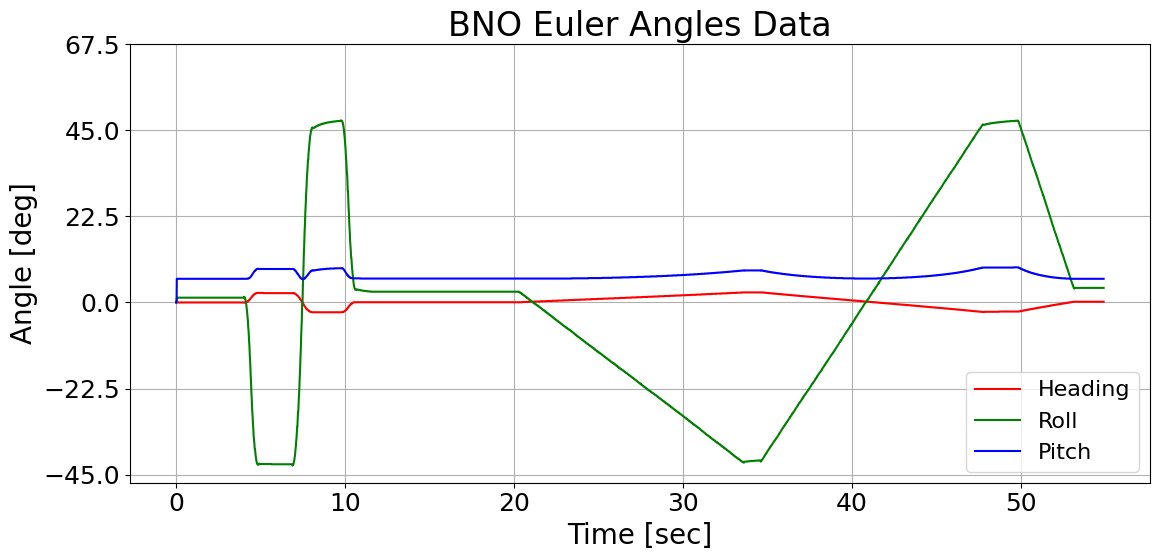

In [13]:
def _unwrap_deg(vals):
    unwrapped = np.rad2deg(np.unwrap(np.deg2rad(vals), discont=np.deg2rad(180.0)))
    offset = np.round(unwrapped[0] / 360.0) * 360.0
    return unwrapped - offset

t_start = 0
t_end = 200

heading = _unwrap_deg(sensor_data['bno']['eul_heading'])
roll = _unwrap_deg(sensor_data['bno']['eul_roll'])
pitch = _unwrap_deg(sensor_data['bno']['eul_pitch'])

full_t = np.arange(len(sensor_data['bno']['eul_heading'])) / sensor_data['bno']['avg_sampling_rate']
mask = (full_t >= t_start) & (full_t <= t_end)
t_plot = full_t[mask] - t_start

plt.rcParams.update({
    "font.size": 20,
    "axes.titlesize": 24,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 16,
})
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(t_plot, heading[mask], label='Heading', color='r')
ax.plot(t_plot, roll[mask], label='Roll', color='g')
ax.plot(t_plot, pitch[mask], label='Pitch', color='b')
ax.set_xlabel('Time [sec]')
ax.set_ylabel('Angle [deg]')
ax.set_title('BNO Euler Angles Data')

all_angles = np.concatenate([heading[mask], roll[mask], pitch[mask]])
y_min, y_max = np.min(all_angles), np.max(all_angles)
span = y_max - y_min

candidate_steps = np.array([22.5, 45.0, 90.0, 180.0])
target_ticks = 8
step = candidate_steps[np.argmin(np.abs(candidate_steps - max(span / target_ticks, 22.5)))]

tick_start = np.floor(y_min / step) * step
tick_end = np.ceil(y_max / step) * step
ax.set_yticks(np.arange(tick_start, tick_end + 0.5 * step, step))
ax.legend()
ax.grid(True)
fig.tight_layout()

pdf_output_path = os.path.join(os.getcwd(), "plots", "bno_euler_angles.pdf")
os.makedirs(os.path.dirname(pdf_output_path), exist_ok=True)
fig.savefig(pdf_output_path, format="pdf", bbox_inches="tight")
print(f"Wrote {pdf_output_path}")

plt.show()


# Plot BNO055 quaternions

In [ ]:
plt.figure(1, figsize=(12, 6))
t = [i / sensor_data['bno']['avg_sampling_rate'] for i in range(len(sensor_data['bno']['quat_w']))]  # Assuming a sampling rate of 3200 Hz for ADXL
plt.plot(t, sensor_data['bno']['quat_w'], label='W', color='r')
plt.plot(t, sensor_data['bno']['quat_x'], label='X', color='g')
plt.plot(t, sensor_data['bno']['quat_y'], label='Y', color='b')
plt.plot(t, sensor_data['bno']['quat_z'], label='Z', color='y')
plt.xlabel('Time [sec]')
plt.ylabel('Output Value')
plt.title('BNO Quaternion Data')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot BNO055 linear acceleration

In [ ]:
plt.figure(1, figsize=(12, 6))
t = [i / sensor_data['bno']['avg_sampling_rate'] for i in range(len(sensor_data['bno']['lia_x']))]  # Assuming a sampling rate of 3200 Hz for ADXL
plt.plot(t, sensor_data['bno']['lia_x'], label='LIA X-axis', color='r')
plt.plot(t, sensor_data['bno']['lia_y'], label='LIA Y-axis', color='g')
plt.plot(t, sensor_data['bno']['lia_z'], label='LIA Z-axis', color='b')
plt.xlabel('Time [sec]')
plt.ylabel('Output Value')
plt.title('BNO Linear Acceleration Data')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot BNO055 gravity data

In [ ]:
plt.figure(1, figsize=(12, 6))
t = [i / sensor_data['bno']['avg_sampling_rate'] for i in range(len(sensor_data['bno']['grv_x']))]  # Assuming a sampling rate of 3200 Hz for ADXL
plt.plot(t, sensor_data['bno']['grv_x'], label='GRV X-axis', color='r')
plt.plot(t, sensor_data['bno']['grv_y'], label='GRV Y-axis', color='g')
plt.plot(t, sensor_data['bno']['grv_z'], label='GRV Z-axis', color='b')
plt.xlabel('Time [sec]')
plt.ylabel('Output Value')
plt.title('BNO Gravity Data')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot BNO055 temperature

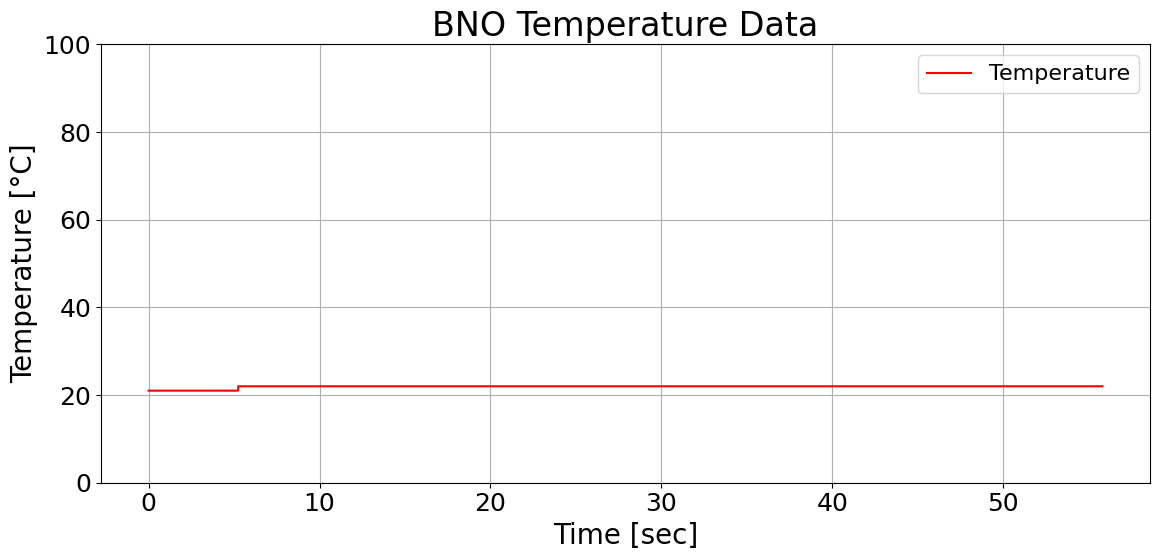

In [29]:
plt.figure(1, figsize=(12, 6))
t = [i / sensor_data['bno']['avg_sampling_rate'] for i in range(len(sensor_data['bno']['temp']))]  # Assuming a sampling rate of 3200 Hz for ADXL
plt.plot(t, sensor_data['bno']['temp'], label='Temperature', color='r')
plt.ylim(0, 100)
plt.xlabel('Time [sec]')
plt.ylabel('Temperature [°C]')
plt.title('BNO Temperature Data')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot piezo data

ADC0 Channel 1: 548864 samples, 9976.59 Hz


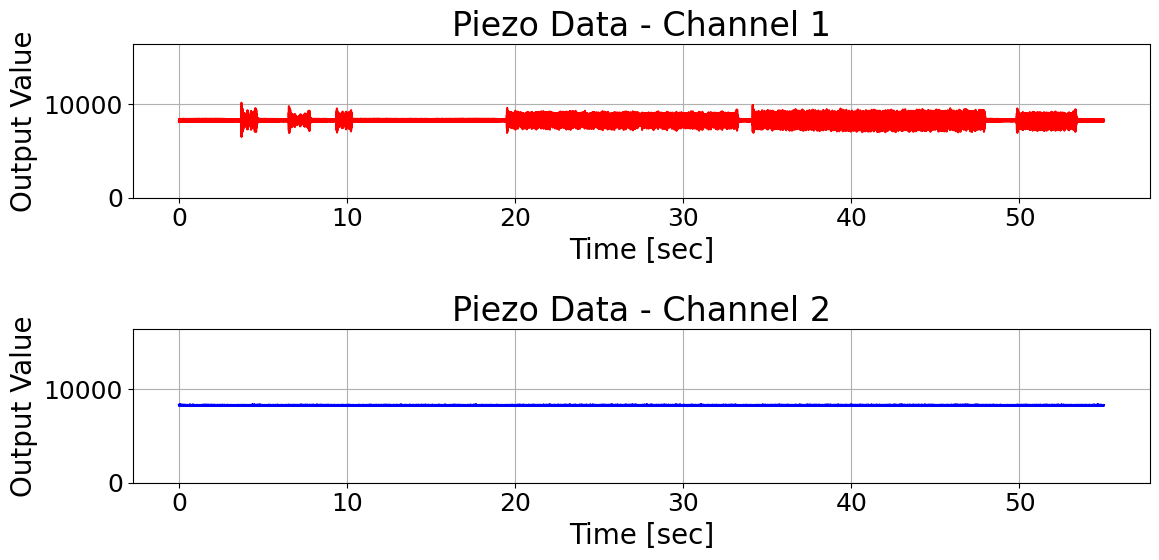

In [61]:
plt.figure(1, figsize=(12, 6))
t = [i / sensor_data['adc0']['avg_sampling_rate'] for i in range(len(sensor_data['adc0']['values_ch1']))]

print(f"ADC0 Channel 1: {len(sensor_data['adc0']['values_ch1'])} samples, {sensor_data['adc0']['avg_sampling_rate']:.2f} Hz")

plt.subplot(2, 1, 1)
plt.plot(t, sensor_data['adc0']['values_ch1'], color='r')
plt.ylim(0, 16383)
plt.xlabel('Time [sec]')
plt.ylabel('Output Value')
plt.title('Piezo Data - Channel 1')
plt.grid(True)
plt.tight_layout()

plt.subplot(2, 1, 2)
plt.plot(t, sensor_data['adc0']['values_ch2'], color='b')
plt.ylim(0, 16383)
plt.xlabel('Time [sec]')
plt.ylabel('Output Value')
plt.title('Piezo Data - Channel 2')
plt.grid(True)
plt.tight_layout()
plt.show()



C:\Users\marek\AppData\Local\Temp\ipykernel_21992\1244655518.py:50: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax_fft[0].set_xlim(0, max_freq_hz)
C:\Users\marek\AppData\Local\Temp\ipykernel_21992\1244655518.py:63: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax_fft[1].set_xlim(0, max_freq_hz)


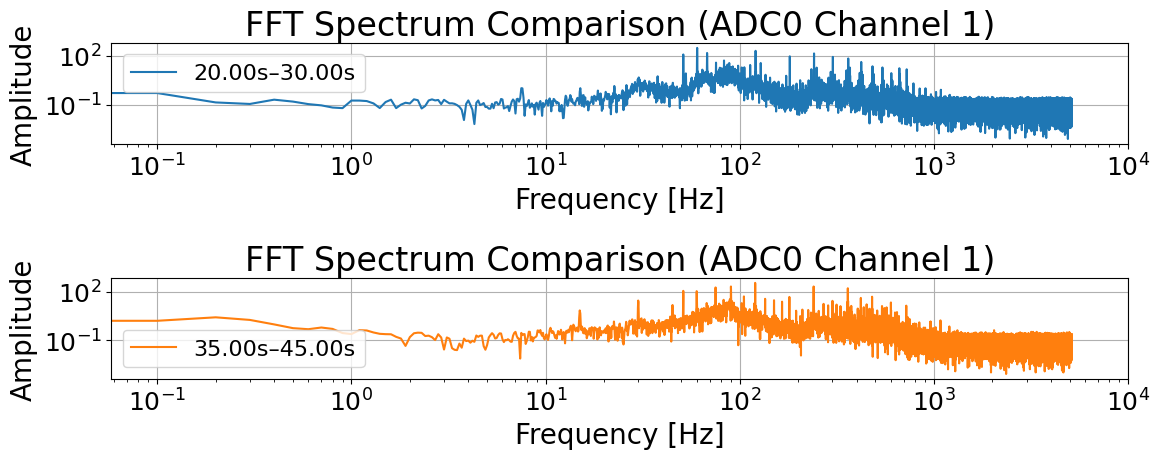

In [31]:
# FFT comparison for two distinct ADXL time windows on one graph

# --- User-defined windows [s] ---
t_start_1 = 20
start_end_1 = 30
t_start_2 = 35
start_end_2 = 45

# Optional display limit
max_freq_hz = 10000

ch1 = np.asarray(sensor_data["adc0"]["values_ch1"], dtype=float)

fs = float(sensor_data["adc0"]["avg_sampling_rate"])
if fs <= 0:
    raise ValueError("Invalid ADC0 sampling rate.")

t_sig = np.arange(len(ch1)) / fs

def fft_from_window(signal, t_axis, t0, t1, fs_hz):
    if t1 <= t0:
        raise ValueError(f"Invalid window: t_start={t0}, t_end={t1}")
    m = (t_axis >= t0) & (t_axis <= t1)
    s = signal[m]
    if len(s) < 8:
        raise ValueError(f"Window [{t0}, {t1}] has too few samples ({len(s)}).")

    s = s - np.mean(s)
    w = np.hanning(len(s))
    yf = np.fft.rfft(s * w)
    xf = np.fft.rfftfreq(len(s), d=1.0 / fs_hz)
    amp = (2.0 / np.sum(w)) * np.abs(yf)
    return xf, amp

f1, a1 = fft_from_window(ch1, t_sig, t_start_1, start_end_1, fs)
f2, a2 = fft_from_window(ch1, t_sig, t_start_2, start_end_2, fs)

fig_fft, ax_fft = plt.subplots(2, 1, figsize=(12, 5))
ax_fft[0].plot(f1, a1, color="tab:blue", label=f"{t_start_1:.2f}s–{start_end_1:.2f}s")

ax_fft[0].set_title("FFT Spectrum Comparison (ADC0 Channel 1)")
ax_fft[0].set_xlabel("Frequency [Hz]")
ax_fft[0].set_ylabel("Amplitude")
ax_fft[0].set_yscale("log")
ax_fft[0].set_xscale("log")
ax_fft[0].grid(True)
ax_fft[0].legend()

if max_freq_hz is not None:
    ax_fft[0].set_xlim(0, max_freq_hz)

ax_fft[1].plot(f2, a2, color="tab:orange", label=f"{t_start_2:.2f}s–{start_end_2:.2f}s")

ax_fft[1].set_title("FFT Spectrum Comparison (ADC0 Channel 1)")
ax_fft[1].set_xlabel("Frequency [Hz]")
ax_fft[1].set_ylabel("Amplitude")
ax_fft[1].set_yscale("log")
ax_fft[1].set_xscale("log")
ax_fft[1].grid(True)
ax_fft[1].legend()

if max_freq_hz is not None:
    ax_fft[1].set_xlim(0, max_freq_hz)

fig_fft.tight_layout()
plt.show()

In [ ]:
import numpy as np
import plotly.graph_objects as go
from IPython.display import display
import time

# Example Euler data
t = np.linspace(0, len(sensor_data['bno']['eul_roll']) / sensor_data['bno']['avg_sampling_rate'], len(sensor_data['bno']['eul_roll']))
roll  = np.array(sensor_data['bno']['eul_roll']) * (np.pi / 180.0)
pitch = np.array(sensor_data['bno']['eul_pitch']) * (np.pi / 180.0)
yaw   = np.array(sensor_data['bno']['eul_heading']) * (np.pi / 180.0)

# Rotation matrix
def rot_matrix(r, p, y):
    Rx = np.array([[1,0,0],
                   [0,np.cos(r),-np.sin(r)],
                   [0,np.sin(r), np.cos(r)]])
    Ry = np.array([[ np.cos(p),0,np.sin(p)],
                   [0,1,0],
                   [-np.sin(p),0,np.cos(p)]])
    Rz = np.array([[np.cos(y),-np.sin(y),0],
                   [np.sin(y), np.cos(y),0],
                   [0,0,1]])
    return Rz @ Ry @ Rx

# Create interactive figure
fig = go.FigureWidget()

# Initial axes
fig.add_trace(go.Scatter3d(x=[0,1], y=[0,0], z=[0,0], mode='lines', line=dict(color='red')))
fig.add_trace(go.Scatter3d(x=[0,0], y=[0,1], z=[0,0], mode='lines', line=dict(color='green')))
fig.add_trace(go.Scatter3d(x=[0,0], y=[0,0], z=[0,1], mode='lines', line=dict(color='blue')))

fig.update_layout(
    scene=dict(
        xaxis=dict(range=[-1,1]),
        yaxis=dict(range=[-1,1]),
        zaxis=dict(range=[-1,1]),
        aspectmode="cube"
    )
)

display(fig)

# Animation loop
for i in range(1, len(t), 10):
    R = rot_matrix(roll[i], pitch[i], yaw[i])

    X = R @ np.array([1,0,0])
    Y = R @ np.array([0,1,0])
    Z = R @ np.array([0,0,1])

    fig.data[0].x = [0, X[0]]
    fig.data[0].y = [0, X[1]]
    fig.data[0].z = [0, X[2]]

    fig.data[1].x = [0, Y[0]]
    fig.data[1].y = [0, Y[1]]
    fig.data[1].z = [0, Y[2]]

    fig.data[2].x = [0, Z[0]]
    fig.data[2].y = [0, Z[1]]
    fig.data[2].z = [0, Z[2]]

    time.sleep(0.1)   # ~10 FPS


FigureWidget({
    'data': [{'line': {'color': 'red'},
              'mode': 'lines',
              'type': 'scatter3d',
              'uid': 'f7a7c4a4-b54b-433f-b324-5af118020c7d',
              'x': [0, 1],
              'y': [0, 0],
              'z': [0, 0]},
             {'line': {'color': 'green'},
              'mode': 'lines',
              'type': 'scatter3d',
              'uid': '583ab918-3c10-4ef0-9c03-f945f2aa1ea7',
              'x': [0, 0],
              'y': [0, 1],
              'z': [0, 0]},
             {'line': {'color': 'blue'},
              'mode': 'lines',
              'type': 'scatter3d',
              'uid': '782530cd-17ad-4f8d-8b3b-cbce1d3c1f01',
              'x': [0, 0],
              'y': [0, 0],
              'z': [0, 1]}],
    'layout': {'scene': {'aspectmode': 'cube',
                         'xaxis': {'range': [-1, 1]},
                         'yaxis': {'range': [-1, 1]},
                         'zaxis': {'range': [-1, 1]}},
               'template